In [63]:
import pandas as pd
import numpy as np

df = pd.read_csv("C:\\Users\\bhoom\\Downloads\\amazon_laptop.csv")
df

,title,price,rating,brand,ram,storage,color,processor
0,"HP 15 (i5 14th Gen), Intel Core 5, 16GB RAM (U...","75,990",3.6,HP,16GB,512GB,Silver,Intel
1,"HP OmniBook 5 OLED (Previously Pavilion), Snap...","79,990",4.1,HP,16GB,512GB,Silver,Snapdragon
2,Lenovo V15 G4 AMD Athlon Silver 7120U Laptop 8...,"44,999",4.0,Lenovo,8GB,512GB,Silver,AMD
3,"ASUS Vivobook 15, Smartchoice,Intel Core i5 13...","65,990",4.1,ASUS,16GB,512GB,Blue,Intel
4,Apple 2026 MacBook Neo 13″ Laptop with A18 Pro...,"73,990",4.7,Apple,8GB,256GB,Silver,NaN
...,...,...,...,...,...,...,...,...
548,"Dell 15 (Previously Inspiron), R5-7520U Proces...","53,990",2.0,Dell,8GB,512GB,Black,NaN
549,Apple 2026 MacBook Neo 13″ Laptop with A18 Pro...,"73,990",4.7,Apple,8GB,256GB,Silver,NaN
550,"Lenovo V14 Intel Core i3 13th Gen 14"" FHD (192...","70,990",3.6,Lenovo,16GB,512GB,Grey,Intel
551,Apple 2026 MacBook Pro Laptop with M5 Pro chip...,"3,42,490",4.5,Apple,24GB,1TB,Black,NaN


In [64]:
# droping the duplicates

df = df.drop_duplicates().copy()

In [65]:
df

,title,price,rating,brand,ram,storage,color,processor
0,"HP 15 (i5 14th Gen), Intel Core 5, 16GB RAM (U...","75,990",3.6,HP,16GB,512GB,Silver,Intel
1,"HP OmniBook 5 OLED (Previously Pavilion), Snap...","79,990",4.1,HP,16GB,512GB,Silver,Snapdragon
2,Lenovo V15 G4 AMD Athlon Silver 7120U Laptop 8...,"44,999",4.0,Lenovo,8GB,512GB,Silver,AMD
3,"ASUS Vivobook 15, Smartchoice,Intel Core i5 13...","65,990",4.1,ASUS,16GB,512GB,Blue,Intel
4,Apple 2026 MacBook Neo 13″ Laptop with A18 Pro...,"73,990",4.7,Apple,8GB,256GB,Silver,NaN
...,...,...,...,...,...,...,...,...
460,HP OmniBook X Flip OLED Intel Core Ultra 5 226...,"1,15,990",3.7,HP,16GB,1TB,Silver,Intel
464,"Acer One15 (2026), AMD Ryzen 3 Quad Core 7320U...","40,990",5.0,Acer,LPDDR5,256GB,Silver,AMD
465,Dell Inspiron 15 DC15250 Laptop (Intel I5-1334...,"58,990",NaN,Dell,8GB,512GB,Black,Intel
471,Apple 2026 MacBook Pro Laptop with M5 Max chip...,"5,13,990",2.4,Apple,36GB,2TB,Silver,NaN


In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 272 entries, 0 to 551
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   title      272 non-null    object 
 1   price      266 non-null    object 
 2   rating     225 non-null    float64
 3   brand      272 non-null    object 
 4   ram        247 non-null    object 
 5   storage    242 non-null    object 
 6   color      241 non-null    object 
 7   processor  244 non-null    object 
dtypes: float64(1), object(7)
memory usage: 19.1+ KB


In [67]:
df["price"].unique()

array(['75,990', '79,990', '44,999', '65,990', '73,990', '70,990',
       '69,990', '67,990', '53,990', '1,72,490', '42,990', '44,990',
       '35,690', '57,490', '62,490', '35,990', '50,500', '38,700',
       '29,990', '69,790', '49,450', '4,64,490', '1,94,990', '61,490',
       '49,990', '28,990', '95,990', '54,990', '58,800', '2,99,990',
       '69,999', '55,990', '60,250', '56,900', '82,990', '53,950',
       '56,880', '85,990', '68,700', '66,400', '3,42,490', '87,990',
       '68,699', '37,400', '24,990', '25,640', '84,990', '47,990',
       '67,999', '48,990', '56,690', '39,890', '77,990', '98,990',
       '53,490', '45,990', '42,999', '66,690', '31,990', '1,29,990',
       '63,990', '68,490', '62,500', '61,200', '66,798', '49,400',
       '59,990', '2,49,990', '1,84,990', '24,900', '57,250', '91,700',
       '59,800', '68,480', nan, '4,82,490', '2,34,454', '89,990',
       '57,990', '43,950', '1,86,990', '54,650', '1,66,990', '62,350',
       '1,70,000', '1,36,990', '3,19,990', 

In [68]:
# cleaning the price col and converting into float

df["price"] = df["price"].astype(str)

df["price"] = df["price"].str.replace(",", "")

df["price"] = df["price"].astype(float)

In [69]:
df["price"]

0       75990.0
1       79990.0
2       44999.0
3       65990.0
4       73990.0
         ...   
460    115990.0
464     40990.0
465     58990.0
471    513990.0
551    342490.0
Name: price, Length: 272, dtype: float64

In [70]:
df["rating"].dtypes

dtype('float64')

In [71]:
for col in ["title", "brand", "ram", "storage", "color", "processor"]:
    df[col] = df[col].astype("string").str.strip()

In [72]:
df["ram"].unique()

<StringArray>
[  '16GB',    '8GB',    'RAM', 'LPDDR4',   'DDR5',    '4GB',   '12GB',
   '36GB',   '24GB',     <NA>,    '6GB',   '32GB', 'LPDDR5',  '128GB',
   '48GB',   'DDR7',   '64GB']
Length: 17, dtype: string

In [73]:
# extracting the numbers only from ram col

df["ram_gb"] = df["ram"].str.replace("GB", "", regex=False)
df["ram_gb"] = pd.to_numeric(df["ram_gb"], errors="coerce")

In [74]:
df["ram_gb"].unique()

<IntegerArray>
[16, 8, <NA>, 4, 12, 36, 24, 6, 32, 128, 48, 64]
Length: 12, dtype: Int64

In [75]:
# droping the nan vals

df = df.dropna(subset=["ram_gb"])

In [76]:
df["ram_gb"].unique()

<IntegerArray>
[16, 8, 4, 12, 36, 24, 6, 32, 128, 48, 64]
Length: 11, dtype: Int64

In [77]:
# same with storage col

df["storage"].unique()

<StringArray>
['512GB', '256GB', '1TB', <NA>, '2TB', '64GB', '128GB', '500GB']
Length: 8, dtype: string

In [78]:
# replacing tb to gb and converting all in numeric

df["storage_gb"] = df["storage"].str.replace("GB", "", regex=False)
df["storage_gb"] = df["storage_gb"].str.replace("TB", "000", regex=False)
df["storage_gb"] = pd.to_numeric(df["storage_gb"], errors="coerce")

C:\Users\bhoom\AppData\Local\Temp\ipykernel_21804\4204719638.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["storage_gb"] = df["storage"].str.replace("GB", "", regex=False)
C:\Users\bhoom\AppData\Local\Temp\ipykernel_21804\4204719638.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["storage_gb"] = df["storage_gb"].str.replace("TB", "000", regex=False)
C:\Users\bhoom\AppData\Local\Temp\ipykernel_21804\4204719638.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice fro

In [79]:
df["storage_gb"].unique()

<IntegerArray>
[512, 256, 1000, <NA>, 2000, 64, 128, 500]
Length: 8, dtype: Int64

In [80]:
df = df.dropna(subset=["storage_gb"])

In [81]:
df["storage_gb"].unique()

<IntegerArray>
[512, 256, 1000, 2000, 64, 128, 500]
Length: 7, dtype: Int64

In [82]:
df["rating"].unique()

array([3.6, 4.1, 4. , 4.7, 3.8, 2. , 1. , 4.2, 5. , 4.8, 3.7, 3.2, 4.3,
       4.4, nan, 4.6, 3.3, 3.9, 3. , 2.8, 3.5, 3.4, 3.1, 4.5, 2.9, 2.4,
       2.7, 4.9, 2.6])

In [83]:
df["rating"].dtypes

dtype('float64')

In [84]:
df = df.dropna(subset=["rating"])

In [85]:
df["rating"] = pd.to_numeric(df["rating"], errors="coerce")

In [86]:
df["rating"].unique()

array([3.6, 4.1, 4. , 4.7, 3.8, 2. , 1. , 4.2, 5. , 4.8, 3.7, 3.2, 4.3,
       4.4, 4.6, 3.3, 3.9, 3. , 2.8, 3.5, 3.4, 3.1, 4.5, 2.9, 2.4, 2.7,
       4.9, 2.6])

In [87]:
# clearing the brand col

df["brand"].unique().value_counts()

HP           1
Lenovo       1
ASUS         1
Apple        1
Dell         1
Acer         1
MaxBook      1
acer         1
Alienware    1
MSI          1
NEW          1
Samsung      1
Microsoft    1
Name: count, dtype: Int64

In [88]:
df=df.replace({"brand":{"acer":"Acer"}})

In [89]:
df["brand"].unique()

<StringArray>
[       'HP',    'Lenovo',      'ASUS',     'Apple',      'Dell',      'Acer',
   'MaxBook', 'Alienware',       'MSI',       'NEW',   'Samsung', 'Microsoft']
Length: 12, dtype: string

In [90]:
df["brand"] = df["brand"].replace("NEW", pd.NA)

In [91]:
df = df.dropna(subset=["brand"])

In [92]:
df["brand"].unique()

<StringArray>
[       'HP',    'Lenovo',      'ASUS',     'Apple',      'Dell',      'Acer',
   'MaxBook', 'Alienware',       'MSI',   'Samsung', 'Microsoft']
Length: 11, dtype: string

In [93]:
#  cleaning color col

df["color"].unique()

<StringArray>
['Silver', 'Blue', 'Grey', 'Black', <NA>, 'Gray', 'Indigo', 'White']
Length: 8, dtype: string

In [94]:
df=df.replace({"color":{"Grey":"Gray"}})

In [95]:
df = df.dropna(subset=["color"])

In [96]:
df["color"].unique()

<StringArray>
['Silver', 'Blue', 'Gray', 'Black', 'Indigo', 'White']
Length: 6, dtype: string

In [97]:
# cleaning processor col

df["processor"].unique()

<StringArray>
['Intel', 'Snapdragon', 'AMD', <NA>, 'MediaTek']
Length: 5, dtype: string

In [98]:
df = df.dropna(subset=["processor"])

In [99]:
df["processor"].unique()

<StringArray>
['Intel', 'Snapdragon', 'AMD', 'MediaTek']
Length: 4, dtype: string

In [100]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 139 entries, 0 to 460
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   title       139 non-null    string 
 1   price       133 non-null    float64
 2   rating      139 non-null    float64
 3   brand       139 non-null    string 
 4   ram         139 non-null    string 
 5   storage     139 non-null    string 
 6   color       139 non-null    string 
 7   processor   139 non-null    string 
 8   ram_gb      139 non-null    Int64  
 9   storage_gb  139 non-null    Int64  
dtypes: Int64(2), float64(2), string(6)
memory usage: 12.2 KB


In [101]:
df

,title,price,rating,brand,ram,storage,color,processor,ram_gb,storage_gb
0,"HP 15 (i5 14th Gen), Intel Core 5, 16GB RAM (U...",75990.0,3.6,HP,16GB,512GB,Silver,Intel,16,512
1,"HP OmniBook 5 OLED (Previously Pavilion), Snap...",79990.0,4.1,HP,16GB,512GB,Silver,Snapdragon,16,512
2,Lenovo V15 G4 AMD Athlon Silver 7120U Laptop 8...,44999.0,4.0,Lenovo,8GB,512GB,Silver,AMD,8,512
3,"ASUS Vivobook 15, Smartchoice,Intel Core i5 13...",65990.0,4.1,ASUS,16GB,512GB,Blue,Intel,16,512
5,"Lenovo V14 Intel Core i3 13th Gen 14"" FHD (192...",70990.0,3.6,Lenovo,16GB,512GB,Gray,Intel,16,512
...,...,...,...,...,...,...,...,...,...,...
440,"acer Aspire Lite, AMD Ryzen 3-7330U, 16GB RAM,...",51990.0,3.3,Acer,16GB,512GB,Gray,AMD,16,512
451,Lenovo LOQ 2025 Intel Core i7-13650HX | NVIDIA...,176990.0,3.9,Lenovo,8GB,1TB,Gray,Intel,8,1000
453,Lenovo LOQ 13th Gen Intel Core i7-13650HX 15.6...,NaN,3.6,Lenovo,16GB,512GB,Gray,Intel,16,512
457,"Lenovo IdeaPad Slim 3, Intel Core i7-13620H, 1...",83400.0,4.1,Lenovo,16GB,512GB,Gray,Intel,16,512


In [102]:
df["price"].unique()

array([ 75990.,  79990.,  44999.,  65990.,  70990.,  69990.,  67990.,
        44990.,  35990.,  69790.,  49450.,  49990.,  28990.,  95990.,
        54990.,  69999.,  55990.,  56900.,  82990.,  53950.,  85990.,
        66400.,  87990.,  68699.,  24990.,  84990.,  47990.,  67999.,
        48990.,  56690.,  39890.,  77990.,  98990.,  45990.,  42999.,
       129990.,  63990.,  68490.,  61200.,  66798.,  49400.,  57250.,
        68480.,     nan, 482490.,  89990.,  43950.,  54650., 166990.,
       170000., 136990.,  58990., 334990., 126990., 290000.,  66990.,
       124900., 165000.,  83465., 231490.,  52990.,  71990.,  55100.,
       155990., 185490.,  57880.,  53999.,  94990., 156555.,  70849.,
       175000.,  91289., 141500., 239990.,  53990.,  59950.,  69499.,
       114990.,  76890., 219990., 148000., 119990., 105540., 103990.,
        66999.,  85024.,  54500.,  62850.,  72900.,  72800., 158990.,
        86990.,  52680.,  56999., 215990., 174500., 431990., 529990.,
        88990., 2734

In [103]:
df = df.dropna(subset=["price"])

In [104]:
df = df.drop(columns=["ram", "storage"])

In [105]:
df

,title,price,rating,brand,color,processor,ram_gb,storage_gb
0,"HP 15 (i5 14th Gen), Intel Core 5, 16GB RAM (U...",75990.0,3.6,HP,Silver,Intel,16,512
1,"HP OmniBook 5 OLED (Previously Pavilion), Snap...",79990.0,4.1,HP,Silver,Snapdragon,16,512
2,Lenovo V15 G4 AMD Athlon Silver 7120U Laptop 8...,44999.0,4.0,Lenovo,Silver,AMD,8,512
3,"ASUS Vivobook 15, Smartchoice,Intel Core i5 13...",65990.0,4.1,ASUS,Blue,Intel,16,512
5,"Lenovo V14 Intel Core i3 13th Gen 14"" FHD (192...",70990.0,3.6,Lenovo,Gray,Intel,16,512
...,...,...,...,...,...,...,...,...
436,"HP 15, (i3 14th Gen) Intel Core 3 100U (8GB DD...",56000.0,4.2,HP,Silver,Intel,8,512
440,"acer Aspire Lite, AMD Ryzen 3-7330U, 16GB RAM,...",51990.0,3.3,Acer,Gray,AMD,16,512
451,Lenovo LOQ 2025 Intel Core i7-13650HX | NVIDIA...,176990.0,3.9,Lenovo,Gray,Intel,8,1000
457,"Lenovo IdeaPad Slim 3, Intel Core i7-13620H, 1...",83400.0,4.1,Lenovo,Gray,Intel,16,512


In [106]:
df.to_csv("amazon_laptop_cleaned.csv", index=False)

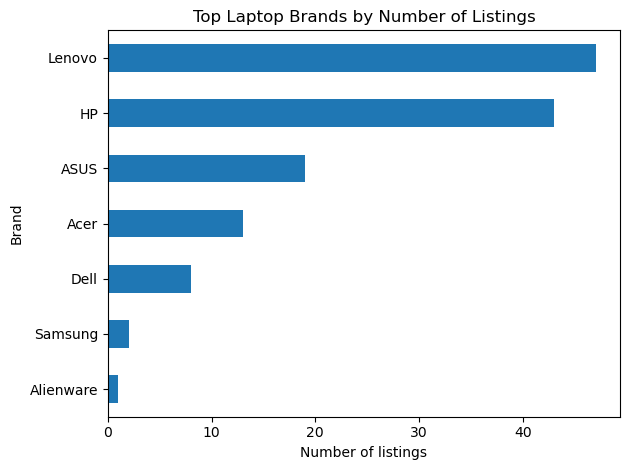

In [107]:
import matplotlib.pyplot as plt

brand_counts = df["brand"].value_counts().head(10)
brand_counts.sort_values().plot(kind="barh")
plt.title("Top Laptop Brands by Number of Listings")
plt.xlabel("Number of listings")
plt.ylabel("Brand")
plt.tight_layout()
plt.show()

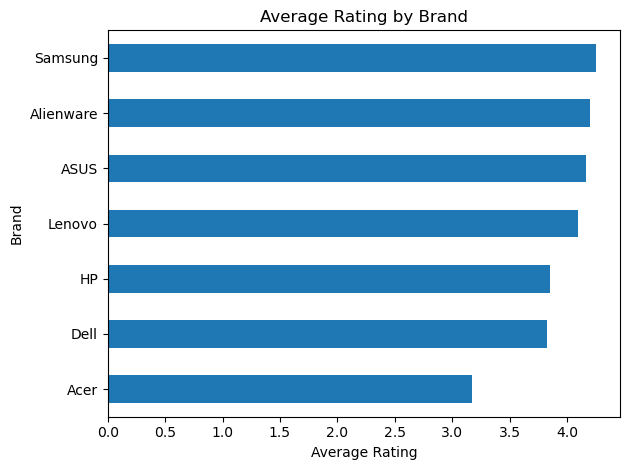

In [109]:
# avg rating by brands

brand_rating = df.groupby("brand")["rating"].mean().sort_values()

brand_rating.plot(kind="barh")

plt.title("Average Rating by Brand")
plt.xlabel("Average Rating")
plt.ylabel("Brand")
plt.tight_layout()
plt.show()

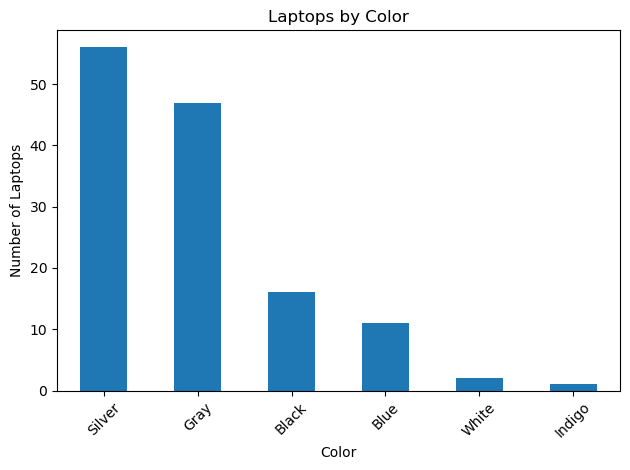

In [110]:
# number of laptops by color

df["color"].value_counts().plot(kind="bar")

plt.title("Laptops by Color")
plt.xlabel("Color")
plt.ylabel("Number of Laptops")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

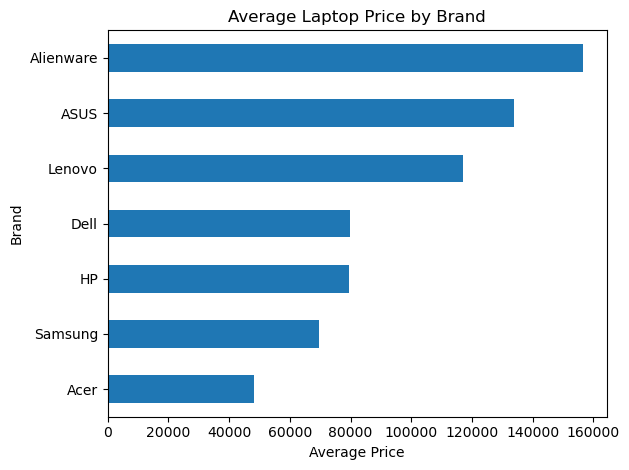

In [112]:
# price 

avg_price = df.groupby("brand")["price"].mean().sort_values()

avg_price.plot(kind="barh")

plt.title("Average Laptop Price by Brand")
plt.xlabel("Average Price")
plt.ylabel("Brand")
plt.tight_layout()
plt.show()

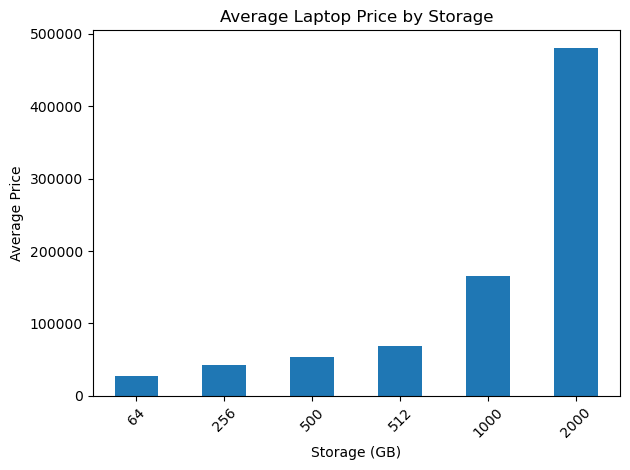

In [113]:
# storage and price

avg_storage_price = df.groupby("storage_gb")["price"].mean().sort_values()

avg_storage_price.plot(kind="bar")

plt.title("Average Laptop Price by Storage")
plt.xlabel("Storage (GB)")
plt.ylabel("Average Price")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()